# Notebook 04: Feature Importance and Multivariable Classification

## 1. Context and Objective
In Notebook 03, we created a baseline classifier using only a single perception variable, achieving an accuracy of 72.86%. However, this single-variable approach proved too shallow to correctly classify boundary cases, such as the Juiz de Fora campus, which resulted in a False Negative.

In this notebook, we expand our model into a **robust, multivariable system** using exclusively the complete set of student exam perception questions from **Arquivo 3**. We will leverage Random Forest's native `feature_importances_` property to automatically rank which contextual and sentiment factors exert the highest impact on institutional success.

In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

RAW_PATH = '../data/raw/'
PROCESSED_PATH = '../data/processed/'

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("✅ Environment configured and paths mapped!")

✅ Environment configured and paths mapped!


## 2. Multivariable Data Loading and Feature Engineering
We load the aggregated baseline performance data. Then, we process the complete raw perception file (`microdados_enade_2025_arq3.txt`) to extract all evaluation variables (`CO_RS_I1` onwards), computing their percentage distribution per course to expand our feature space.

In [6]:
df_base = pd.read_csv(os.path.join(PROCESSED_PATH, 'enamed_2025_aggregated_performance.csv'))

median_score = df_base['avg_score_general'].median()
df_base['performance_class'] = np.where(df_base['avg_score_general'] >= median_score, 1, 0)

df_arq3 = pd.read_csv(os.path.join(RAW_PATH, 'microdados_enade_2025_arq3.txt'), sep=';', decimal='.')
df_arq3_present = df_arq3[df_arq3['TP_PR_GER'] == 555].copy()

perception_cols = [col for col in df_arq3_present.columns if 'CO_RS_' in col or 'PERCEPCAO' in col]

df_features_all = pd.DataFrame({'CO_CURSO': df_base['CO_CURSO']})

print("Processing complete Arquivo 3 perception columns...")
for col in perception_cols:
    ct = pd.crosstab(df_arq3_present['CO_CURSO'], df_arq3_present[col], normalize='index') * 100
    ct.columns = [f'pct_{col}_{resp}' for resp in ct.columns]
    df_features_all = pd.merge(df_features_all, ct.reset_index(), on='CO_CURSO', how='left')

df_ml_multi = pd.merge(df_base, df_features_all, on='CO_CURSO', how='inner')
df_ml_multi = df_ml_multi.fillna(df_ml_multi.median(numeric_only=True))

print(f"\nData fusion complete!")
print(f"Total courses for the model: {df_ml_multi.shape[0]}")
print(f"Total predictive features generated: {len([c for c in df_ml_multi.columns if 'pct_' in c])}")

Processing complete Arquivo 3 perception columns...

Data fusion complete!
Total courses for the model: 350
Total predictive features generated: 60


## 3. Data Splitting and Feature Scaling
We separate our 60 newly generated predictive features ($X$) from the target variable ($y$), partition the dataset into training (80%) and testing (20%) sets, and apply standard scaling.

In [7]:
feature_cols = [col for col in df_ml_multi.columns if 'pct_' in col]
X = df_ml_multi[feature_cols]
y = df_ml_multi['performance_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data split successful. Training shape: {X_train.shape} | Testing shape: {X_test.shape}")

Data split successful. Training shape: (280, 60) | Testing shape: (70, 60)


## 4. Multivariable Model Training and Feature Importance Extraction
We fit a Random Forest classifier onto the complete perception feature space. Once trained, we extract its native `feature_importances_` to isolate and rank the top 15 most influential perception dynamics impacting exam performance.

Multivariable Random Forest Accuracy: 0.6857



C:\Users\lucas\AppData\Local\Temp\ipykernel_24300\2030086510.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


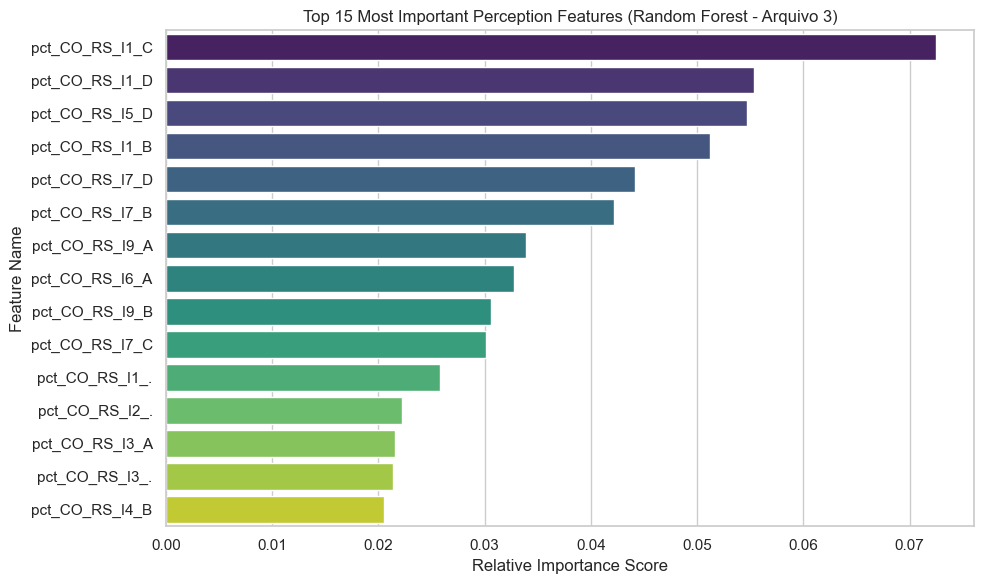

In [8]:
rf_multi = RandomForestClassifier(random_state=42, n_estimators=150, max_depth=5)
rf_multi.fit(X_train_scaled, y_train)

y_pred = rf_multi.predict(X_test_scaled)
multi_acc = accuracy_score(y_test, y_pred)
print(f"Multivariable Random Forest Accuracy: {multi_acc:.4f}\n")

importances = rf_multi.feature_importances_
df_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_importance.head(15), 
    palette='viridis'
)
plt.title('Top 15 Most Important Perception Features (Random Forest - Arquivo 3)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## 5. Feature Importance Interpretation and Insights

Analyzing the top 15 features generated natively by our Random Forest model reveals critical patterns about how student perception shapes institutional classification:

* **Dominance of Question 1 (`CO_RS_I1`):** Features representing specific options of `CO_RS_I1` (such as `pct_CO_RS_I1_C`, `pct_CO_RS_I1_D`, and `pct_CO_RS_I1_B`) hold the highest relative importance scores. This validates our choice in Notebook 03 to use it as the initial baseline predictor.
* **Secondary Key Factors:** Beyond overall exam difficulty, questions like `CO_RS_I5` (exam length/time management) and `CO_RS_I7` (clarity/formatting of the exam items) appear with high importance weights.
* **Granular Multi-Feature Advantage:** While using a single variable previously oversimplified boundaries, expanding the data into 60 distinct response proportions allows the Random Forest to capture subtle contextual combinations. For instance, a high concentration of intermediate answers (like option 'C') across multiple courses provides a massive amount of discriminative information for splitting high and low-performance institutions.

## 6. Model Evaluation and Local UFJF Predictions
We print the final evaluation metrics to check if expanding the feature space improved overall accuracy and test the new model directly on the UFJF campuses (Juiz de Fora and Governador Valadares) to observe if the multivariable data fixed the previous false negative.

In [9]:
print("=== GLOBAL MODEL METRICS ===")
print(classification_report(y_test, y_pred))

print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

# UFJF Local Testing
df_ufjf = df_ml_multi[df_ml_multi['CO_CURSO'].isin([13103, 5001167])].copy()

if not df_ufjf.empty:
    X_ufjf = df_ufjf[feature_cols]
    X_ufjf_scaled = scaler.transform(X_ufjf)
    
    preds_ufjf = rf_multi.predict(X_ufjf_scaled)
    probs_ufjf = rf_multi.predict_proba(X_ufjf_scaled)
    
    print("\n=== UFJF REGIONAL PREDICTIONS ===")
    for idx, row in df_ufjf.reset_index(drop=True).iterrows():
        campus_name = "Juiz de Fora" if row['CO_CURSO'] == 13103 else "Governador Valadares"
        pred_class = "High Performance" if preds_ufjf[idx] == 1 else "Low Performance"
        actual_class = "High Performance" if row['performance_class'] == 1 else "Low Performance"
        confidence = probs_ufjf[idx][preds_ufjf[idx]] * 100
        
        print(f"Campus: {campus_name} ({int(row['CO_CURSO'])})")
        print(f"  Prediction: {pred_class} ({confidence:.1f}% confidence)")
        print(f"  Actual Exam Class: {actual_class}\n")
else:
    print("⚠️ UFJF courses not found in the processed subset.")

=== GLOBAL MODEL METRICS ===
              precision    recall  f1-score   support

           0       0.72      0.68      0.70        38
           1       0.65      0.69      0.67        32

    accuracy                           0.69        70
   macro avg       0.68      0.69      0.68        70
weighted avg       0.69      0.69      0.69        70

=== CONFUSION MATRIX ===
[[26 12]
 [10 22]]

=== UFJF REGIONAL PREDICTIONS ===
Campus: Juiz de Fora (13103)
  Prediction: High Performance (59.5% confidence)
  Actual Exam Class: High Performance

Campus: Governador Valadares (5001167)
  Prediction: High Performance (62.6% confidence)
  Actual Exam Class: High Performance

